In [20]:
from hnn_core import jones_2009_model, simulate_dipole
from hnn_core.network_models import add_erp_drives_to_jones_model
from hnn_core.extracellular import calculate_csd2d, _get_laminar_z_coords

import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.spatial.distance import cdist
import ot

In [16]:
def plot_full_csd(csd_data, times, layer_boundaries, vmin=-60, vmax=60, title='Laminar CSD', xmin=None, xmax=None):
        plt.figure(figsize=(7,5))
        plt.imshow(csd_data, aspect='auto', cmap='jet_r',
                extent=[times[0], times[-1], 0, csd_data.shape[0]],
                vmin=vmin, vmax=vmax)
        plt.colorbar()
        plt.xlim(xmin, xmax)
        plt.axvline(0, color='w')

        # layer_boundaries_exp = num_contacts_exp - np.array([l2_indices_exp[0], l2_indices_exp[-1], l5_indices_exp[0], l5_indices_exp[-1]])
        plt.hlines(xmin=xmin, xmax=xmax, y=layer_boundaries, color='k', linestyle='--')
        plt.xlabel('Time (ms)')
        plt.ylabel('Contact No.')

        plt.title(title)


def plot_csd_layers(l2_data, l5_data, times, vmin=-60, vmax=60, xmin=None, xmax=None):
        plt.figure(figsize=(7,5))
        plt.subplot(2,1,1)
        plt.imshow(l2_data, aspect='auto', cmap='jet_r',
                        extent=[times[0], times[-1], 0, l2_data.shape[0]],
                        vmin=vmin, vmax=vmax)

        plt.xlim(xmin, xmax)
        plt.axvline(0, color='w', linestyle='-')
        plt.ylabel('Contact No.')
        plt.title('Layer 2/3 CSD')
        plt.colorbar()

        plt.subplot(2,1,2)
        plt.imshow(l5_data, aspect='auto', cmap='jet_r',
                extent=[times[0], times[-1], 0, l5_data.shape[0]],
                vmin=vmin, vmax=vmax)
        plt.xlim(xmin, xmax)
        plt.axvline(0, color='w', linestyle='-')
        plt.xlabel('Time (ms)')
        plt.ylabel('Contact No.')
        plt.title('Layer 5 CSD')
        plt.colorbar()
        plt.tight_layout()

def _grid_coords(shape: tuple[int, int]) -> np.ndarray:
    """
    Return an (H*W, 2) array of (row, col) coordinates for every cell.
    Coordinates are normalised to [0, 1] so that distance is grid-size invariant.
    """
    H, W = shape
    rows, cols = np.meshgrid(
        np.linspace(0, 1, H),
        np.linspace(0, 1, W),
        indexing="ij",
    )
    return np.column_stack([rows.ravel(), cols.ravel()])   # shape (H*W, 2)


def _normalise(weights: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Normalise a flat non-negative weight vector to sum to 1."""
    w = np.clip(weights, 0, None)
    total = w.sum()
    if total < eps:
        raise ValueError("Heatmap has no positive mass — all values are zero or negative.")
    return w / total


def _process_csd(net):
    contact_labels, delta = _get_laminar_z_coords(net.rec_arrays['shank1'].positions)
    num_contacts = len(contact_labels)

    csd_data = calculate_csd2d(lfp_data=net.rec_arrays['shank1'].voltages[0], delta=delta)


    # "More generally, traces 5–9 fall in L2/3, and traces 15–18 fall in L5." - Anna C.
    l2_indices = np.array(list(range(5, 12)))
    l5_indices = np.array(list(range(16, 26)))

    # Extract layer 2/3 and layer 5 data
    l2_data = csd_data[l2_indices, :]
    l5_data = csd_data[l5_indices, :]

    l2_data_pos, l2_data_neg = l2_data.copy(), l2_data.copy()
    l5_data_pos, l5_data_neg = l5_data.copy(), l5_data.copy()

    l2_data_pos[l2_data_pos < 0] = 0.0
    l2_data_neg[l2_data_neg > 0] = 0.0
    l5_data_pos[l5_data_pos < 0] = 0.0
    l5_data_neg[l5_data_neg > 0] = 0.0
    
    return l2_data_pos, l2_data_neg, l5_data_pos, l5_data_neg



def _wasserstein_csd(
    initial_net,
    initial_params,
    set_params,
    predicted_params,
    update_params,
    obj_values,
    tstop,
    obj_fun_kwargs,
):
    """The objective function for evoked responses.

    Parameters
    ----------
    initial_net : instance of Network
        The network object.
    initial_params : dict
        Keys are parameter names, values are initial parameters.
    set_params : func
        User-defined function that sets network drives and parameters.
    predicted_params : list
        Parameters selected by the optimizer.
    update_params : func
        Function to update params.
    tstop : float
        The simulated dipole's duration.
    target : instance of Dipole
        A dipole object with experimental data.
    n_trials : int
        Number of trials to simulate and average.
    verbose : bool
        If True, print build steps and simulation progress to console. Default: True.

    Returns
    -------
    obj : float
        Normalized RMSE between recorded and simulated dipole.
    """
    is_batch = _check_is_batch(predicted_params)

    if is_batch:
        # params = update_params(initial_params, predicted_params)
        predicted_params = np.array(predicted_params).reshape(-1, len(initial_params))
        params_batch = {
            name: predicted_params[:, idx]
            for idx, name in enumerate(initial_params.keys())
        }

        # simulate dpl with predicted params
        new_net = initial_net.copy()

        def set_params_batch(a, b):
            set_params(b, a)  # need to fix this

        batch_simulation = BatchSimulate(
            net=new_net,
            set_params=set_params_batch,
            save_outputs=False,
            save_dpl=True,
            dt=obj_fun_kwargs.get("dt", 0.025),
            n_trials=obj_fun_kwargs.get("n_trials", 1),
            tstop=tstop,
            overwrite=False,
            clear_cache=False,
        )

        res = batch_simulation.run(
            params_batch,
            n_jobs=obj_fun_kwargs.get("n_jobs", 1),
            combinations=False,
            backend="loky",
            verbose=obj_fun_kwargs.get("verbose", True),
        )

        l2_data_pos_list, l2_data_neg_list, l5_data_pos_list, l5_data_neg_list = list(), list(), list(), list()
        for batch_res in res["simulated_data"]:
            for data in batch_res:
                # smooth & scale all dipoles
                l2_data_pos, l2_data_neg, l5_data_pos, l5_data_neg = _process_csd(data["net"])

                l2_data_pos_list.append(l2_data_pos)
                l2_data_neg_list.append(l2_data_neg)
                l5_data_pos_list.append(l5_data_pos)
                l5_data_neg_list.append(l5_data_neg)

        obj1 = [np.corrcoef(csd_res, obj_fun_kwargs["target"][0])[0,1] for csd_res in csd1_list]
        obj2 = [np.corrcoef(csd_res, obj_fun_kwargs["target"][1])[0,1] for csd_res in csd2_list]

        obj1 = 1 - np.array(obj1)
        obj2 = 1 - np.array(obj2)

        obj =  (obj1 + obj2) / 2
        obj_values.append(obj.tolist())

        print(f"Mean Loss: {np.mean(obj1):.2f}/{np.mean(obj2):.2f} ; Min Loss: {np.min(obj1):.2f}/{np.min(obj2):.2f}")
        return obj

    else:
        params = update_params(initial_params, predicted_params)

        # simulate dpl with predicted params
        new_net = initial_net.copy()
        set_params(new_net, params)

        dpls = simulate_dipole(
            new_net, tstop=tstop, n_trials=obj_fun_kwargs["n_trials"]
        )

        # smooth & scale all dipoles
        _preprocess_dipole(dpls, obj_fun_kwargs)
        dpl = average_dipoles(dpls)
        obj = _corr(dpl, obj_fun_kwargs["target"], tstop=tstop)

    print(f"Mean Loss: {np.mean(obj):.2f}; Min Loss: {np.min(obj):.2f}")
    obj_values.append(obj)

    return obj


### Prepare simulated CSD data

In [3]:
n_trials = 1
scaling_factor = 1000
window_length = 40
tstop = 250
# dt = 0.025
dt = 0.5

net = jones_2009_model()
add_erp_drives_to_jones_model(net)

depths = np.arange(-600, 2150, 100)[::-1] # ordering: pial surface -> inward
electrode_pos = [(135, 135, dep) for dep in depths]
net.add_electrode_array('shank1', electrode_pos)

dpl = simulate_dipole(net, tstop=tstop, dt=dt, verbose=False)

In [11]:
times_hnn = dpl[0].times

contact_labels, delta = _get_laminar_z_coords(net.rec_arrays['shank1'].positions)
num_contacts_hnn = len(contact_labels)

csd_data_hnn = calculate_csd2d(lfp_data=net.rec_arrays['shank1'].voltages[0], delta=delta)


# "More generally, traces 5–9 fall in L2/3, and traces 15–18 fall in L5." - Anna C.
l2_indices_hnn = np.array(list(range(5, 12)))
l5_indices_hnn = np.array(list(range(16, 26)))
layer_boundaries_hnn = num_contacts_hnn - np.array([l2_indices_hnn[0], l2_indices_hnn[-1], l5_indices_hnn[0], l5_indices_hnn[-1]])

# Extract layer 2/3 and layer 5 data
l2_data_hnn = csd_data_hnn[l2_indices_hnn, :]
l5_data_hnn = csd_data_hnn[l5_indices_hnn, :]

l2_data_hnn_pos, l2_data_hnn_neg = l2_data_hnn.copy(), l2_data_hnn.copy()
l5_data_hnn_pos, l5_data_hnn_neg = l5_data_hnn.copy(), l5_data_hnn.copy()

l2_data_hnn_pos[l2_data_hnn_pos < 0] = 0.0
l2_data_hnn_neg[l2_data_hnn_neg > 0] = 0.0
l5_data_hnn_pos[l5_data_hnn_pos < 0] = 0.0
l5_data_hnn_neg[l5_data_hnn_neg > 0] = 0.0

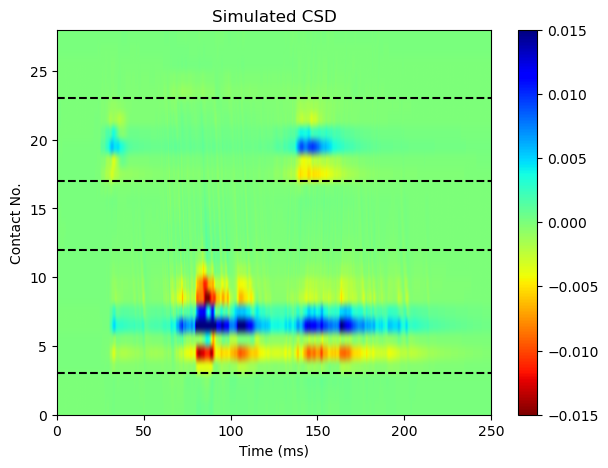

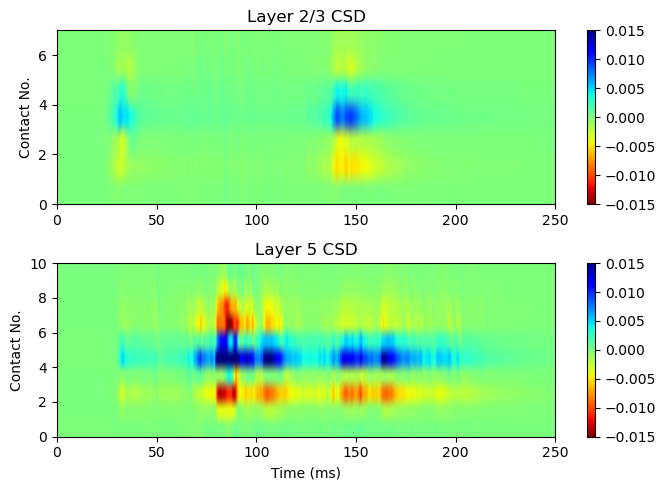

In [12]:
plot_full_csd(csd_data_hnn, times_hnn, layer_boundaries_hnn,
              title='Simulated CSD', vmin=-0.015, vmax=0.015, xmin=0, xmax=250)
plot_csd_layers(l2_data_hnn, l5_data_hnn, times_hnn, xmin=0, xmax=250, vmin=-0.015, vmax=0.015)

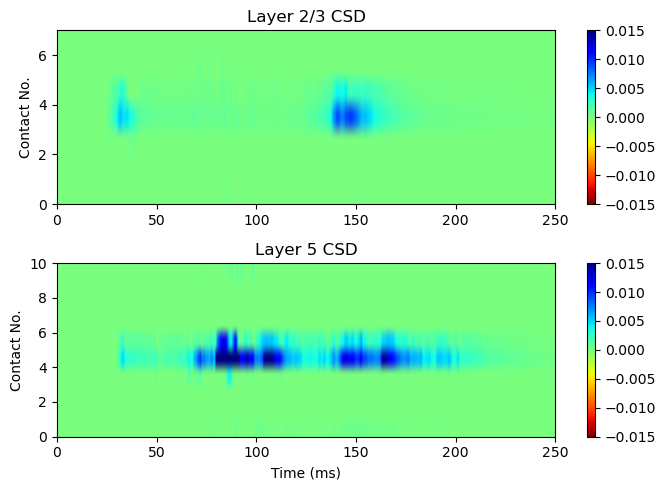

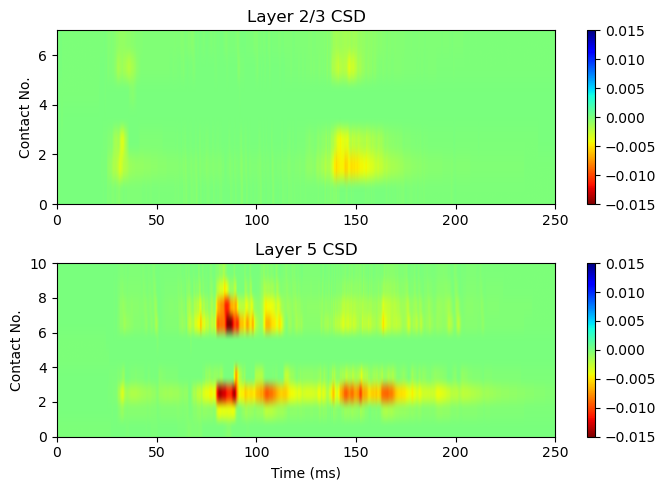

In [13]:
plot_csd_layers(l2_data_hnn_pos, l5_data_hnn_pos, times_hnn, xmin=0, xmax=250, vmin=-0.015, vmax=0.015)
plot_csd_layers(l2_data_hnn_neg, l5_data_hnn_neg, times_hnn, xmin=0, xmax=250, vmin=-0.015, vmax=0.015)

In [32]:
shape = l2_data_hnn.shape
p = 2


coords = _grid_coords(shape)              # (N, 2), values in [0, 1]
D = cdist(coords, coords, metric="euclidean")
M = D ** p                                # cost = dist^p


A = l2_data_hnn_pos
B = l2_data_hnn_pos

a = _normalise(A.ravel())
b = _normalise(B.ravel())
W = (ot.emd2(a, b, M)) ** (1/p)


In [33]:
W

0.0